In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt


from GordonRitter.utils.bet_sizing_model_utils import BetSizingModel
from GordonRitter.utils.bet_sizing_env import TradingEnvironment


In [4]:

data = pd.read_csv('Data/RL_Data_opt_timing.csv')

state_columns = ['bid_price_1', 'bid_size_1', 'open', 'volume','daily_volume', 'volatility']

#optimal points per day
optm_pts_per_day = 20

# Unifying the type of numerical columns 
float_cols = data.select_dtypes(include=['float','int']).columns
data[float_cols] = data[float_cols].astype(np.float32)

#Handling missing values
rows_with_nan = data.isna().any(axis=1)
data.loc[rows_with_nan] = data.ffill().loc[rows_with_nan]
for col in data.columns:
    if data[col].isna().any():
        print(col)

print(f'Data shape:{data.shape}')

train_split = (int(data.shape[0]*0.8)//optm_pts_per_day)*optm_pts_per_day

data_train = data.iloc[:train_split]
data_test = data.iloc[train_split:]

# Min-Max normalization
data_min = data_train[float_cols].min()
data_max = data_train[float_cols].max()

data_max.to_csv('bet_sizing_v1/max_values_to_resize_features.csv', header=True)
data_min.to_csv('bet_sizing_v1/min_values_to_resize_features.csv', header=True)


for col in float_cols:
    data_train[col] = (data_train[col] - data_min[col])/(data_max[col]-data_min[col])
    data_test[col] = (data_test[col] - data_min[col])/(data_max[col]-data_min[col])



Data shape:(20720, 29)


/tmp/ipykernel_26617/2508365960.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_train[col] = (data_train[col] - data_min[col])/(data_max[col]-data_min[col])
/tmp/ipykernel_26617/2508365960.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test[col] = (data_test[col] - data_min[col])/(data_max[col]-data_min[col])


/home/malhar/Workspace/Blockhouse/Blockhouse-ML/blockhouse_ml/equities/sell/utils/data_handler.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data['mid_price'] = (self.data['high'] + self.data['low']) / 2
/home/malhar/Workspace/Blockhouse/Blockhouse-ML/blockhouse_ml/equities/sell/utils/data_handler.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data["mean_vol"] = self.data['mid_price'].pct_change().rolling(window=window_size).mean()
/home/malhar/Workspace/Blockhouse/Blockhouse-ML/block

Training from scratch...
--------------------------------------------------
Actions:0
Number of steps:0
Remaining inventory: 10000
Day End: False
--------------------------------------------------
Reward per trade: 0.9995518871990052
Actions:2
Number of steps:2
Remaining inventory: 0
Day End: False
--------------------------------------------------
Reward per trade: -14.0013567082088
Actions:1
Number of steps:6
Remaining inventory: 0
Day End: False
--------------------------------------------------
Reward per trade: -4.000270316909134
Actions:2
Number of steps:6
Remaining inventory: 0
Day End: False
--------------------------------------------------
Reward per trade: -0.00038536317847925883
Actions:1
Number of steps:2
Remaining inventory: 0
Day End: False
--------------------------------------------------
Reward per trade: -1.9990544290226855
Actions:1
Number of steps:3
Remaining inventory: 0
Day End: False
--------------------------------------------------
Reward per trade: 0.00067450

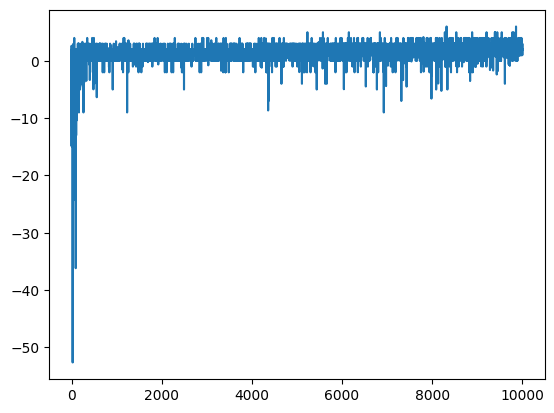

In [3]:

#Enviroment prep
env = TradingEnvironment(
    data=data_train,
    reset_count=optm_pts_per_day,
    initial_inventory=10000,
    state_columns=state_columns
)

model = BetSizingModel(name='model', env=env, overide=True, model_dir='bet_sizing_v1')

#Training the model
model.train(20000)

plt.plot(env.reward_trajectory)

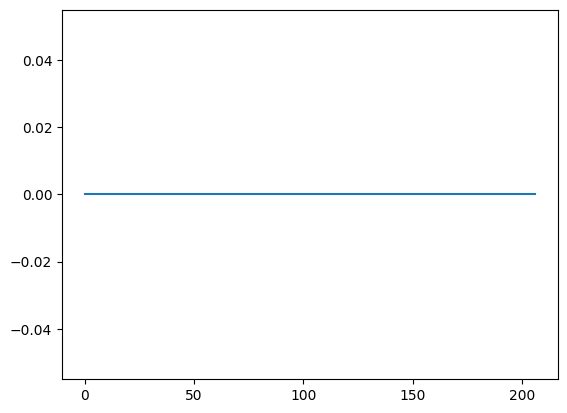

In [9]:
plt.plot(env.initial_inventory_log)

In [10]:
env = TradingEnvironment(
    data=data_test,
    reset_count=optm_pts_per_day,
    initial_inventory=10000,
    state_columns=state_columns
)

model = BetSizingModel(name='model', env=env, model_dir='bet_sizing_v1')

/home/malhar/Workspace/Blockhouse/Blockhouse-ML/blockhouse_ml/equities/sell/utils/data_handler.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data['mid_price'] = (self.data['high'] + self.data['low']) / 2
/home/malhar/Workspace/Blockhouse/Blockhouse-ML/blockhouse_ml/equities/sell/utils/data_handler.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data["mean_vol"] = self.data['mid_price'].pct_change().rolling(window=window_size).mean()
/home/malhar/Workspace/Blockhouse/Blockhouse-ML/block

Model loaded from bet_sizing_v1/model.zip


/home/malhar/Workspace/Blockhouse/Blockhouse-ML/blockhouse_ml/equities/sell/utils/data_handler.py:104: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data['transaction_cost'] = self.data.apply(almgren, axis=1)
/home/malhar/Workspace/Blockhouse/Blockhouse-ML/GordonRitter/utils/bet_sizing_env.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data.ffill(inplace=True)
/home/malhar/miniconda3/envs/blockhouse/lib/python3.9/site-packages/stable_baselines3/common/save_util.py:418: FutureWarning: You are using `torch.load` with `weights_only=False` (the curren

In [11]:
model.test(env=env)

--------------------------------------------------
Actions:0
Number of steps:0
Remaining inventory: 10000
Day End: False
--------------------------------------------------
Reward per trade: -0.6482669027547432
Actions:3
Number of steps:6
Remaining inventory: 0
Day End: False
--------------------------------------------------
Reward per trade: -0.5014317170402594
Actions:2
Number of steps:4
Remaining inventory: 0
Day End: False
--------------------------------------------------
Reward per trade: -1.4331674954841103
Actions:2
Number of steps:4
Remaining inventory: 0
Day End: False
--------------------------------------------------
Reward per trade: -5.628433195221064
Actions:3
Number of steps:9
Remaining inventory: 0
Day End: False
--------------------------------------------------
Reward per trade: -5.390976260830518
Actions:2
Number of steps:8
Remaining inventory: 0
Day End: False
--------------------------------------------------
Reward per trade: 0.9969023657951389
Actions:1
Number o

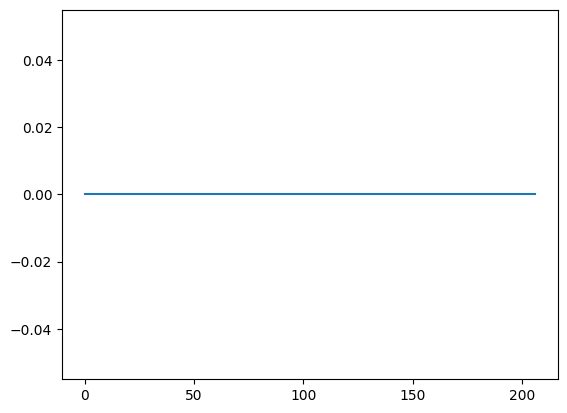

In [13]:
plt.plot(env.initial_inventory_log)

In [14]:
for trade in env.tradelist:
    print(pd.DataFrame(trade, columns=['timestamp', 'volume']))

                   timestamp  volume
0  2024-07-10 18:43:00+00:00   10000
                   timestamp  volume
0  2024-07-10 19:03:00+00:00    4398
1  2024-07-10 19:19:00+00:00    3611
2  2024-07-10 19:20:00+00:00    1991
                   timestamp  volume
0  2024-07-10 19:53:00+00:00       0
1  2024-07-10 19:54:00+00:00       0
2  2024-07-10 19:55:00+00:00    4440
3  2024-07-10 19:56:00+00:00       0
4  2024-07-10 19:58:00+00:00       0
5  2024-07-11 16:02:00+00:00       0
6  2024-07-11 16:03:00+00:00       0
7  2024-07-11 16:04:00+00:00    5560
                   timestamp  volume
0  2024-07-11 17:50:00+00:00       0
1  2024-07-11 17:51:00+00:00   10000
                   timestamp  volume
0  2024-07-11 18:27:00+00:00       0
1  2024-07-11 18:28:00+00:00       0
2  2024-07-11 18:29:00+00:00    5963
3  2024-07-11 18:30:00+00:00    4037
                   timestamp  volume
0  2024-07-11 19:05:00+00:00    7148
1  2024-07-11 19:06:00+00:00       0
2  2024-07-11 19:07:00+00:00    2852
 